<class 'numpy.ndarray'>
(512, 512, 3)
uint8


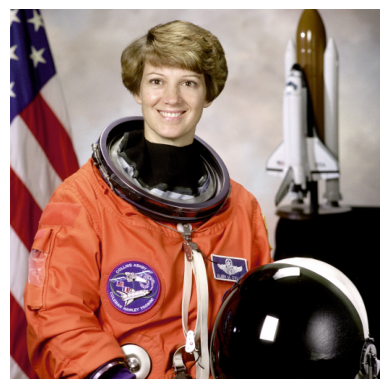

In [7]:
from skimage import data
import matplotlib.pyplot as plt

img = data.astronaut()

print(type(img))
print(img.shape)
print(img.dtype)

plt.imshow(img)
plt.axis("off")
plt.show()


Тип: <class 'numpy.ndarray'>
Размер: (512, 512, 3)
Тип данных: uint8
Пиксель [0, 0]: [154 147 151]
Пиксель [100, 200]: [81 57 17]


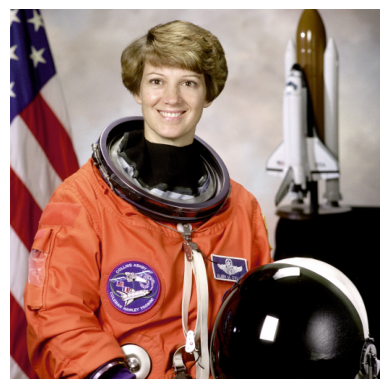

In [8]:
from skimage import data
import matplotlib.pyplot as plt

img = data.astronaut()

print("Тип:", type(img))
print("Размер:", img.shape)
print("Тип данных:", img.dtype)

print("Пиксель [0, 0]:", img[0, 0])
print("Пиксель [100, 200]:", img[100, 200])

plt.imshow(img)
plt.axis("off")
plt.show()


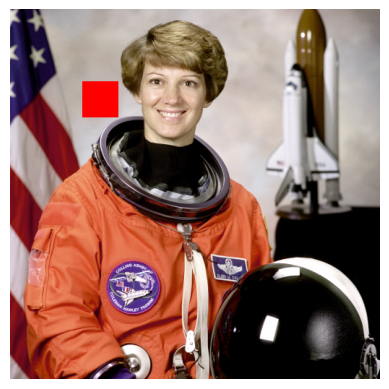

In [9]:
from skimage import data
import matplotlib.pyplot as plt

img = data.astronaut()
img_copy = img.copy()

img_copy[100:150, 100:150] = [255, 0, 0]

plt.imshow(img_copy)
plt.axis("off")
plt.show()


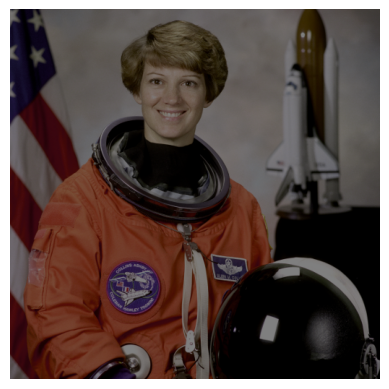

In [10]:
from skimage import data
import matplotlib.pyplot as plt
import numpy as np

img = data.astronaut()

dark = img * 0.5
dark = dark.astype(np.uint8)

plt.imshow(dark)
plt.axis("off")
plt.show()


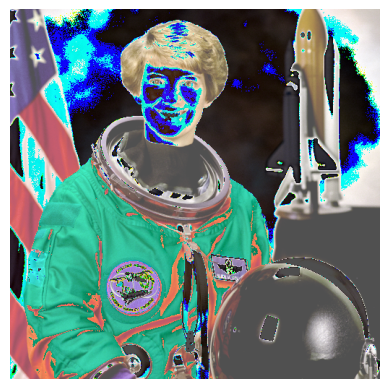

In [11]:
from skimage import data
import matplotlib.pyplot as plt
import numpy as np

img = data.astronaut()

bright = img + 80
bright = np.clip(bright, 0, 255).astype(np.uint8)

plt.imshow(bright)
plt.axis("off")
plt.show()


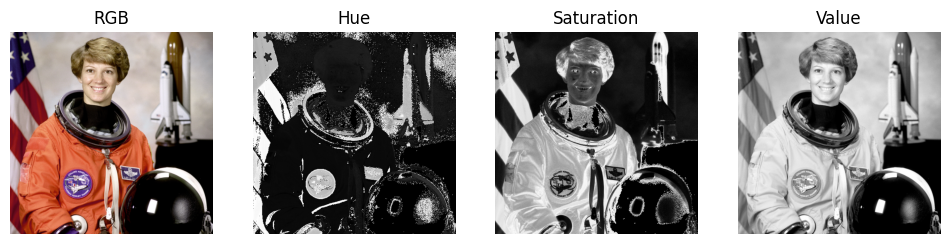

In [14]:
from skimage import data
import matplotlib.pyplot as plt
import cv2

img_rgb = data.astronaut()

img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

h = img_hsv[:, :, 0]
s = img_hsv[:, :, 1]
v = img_hsv[:, :, 2]

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(h, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(s, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(v, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.show()


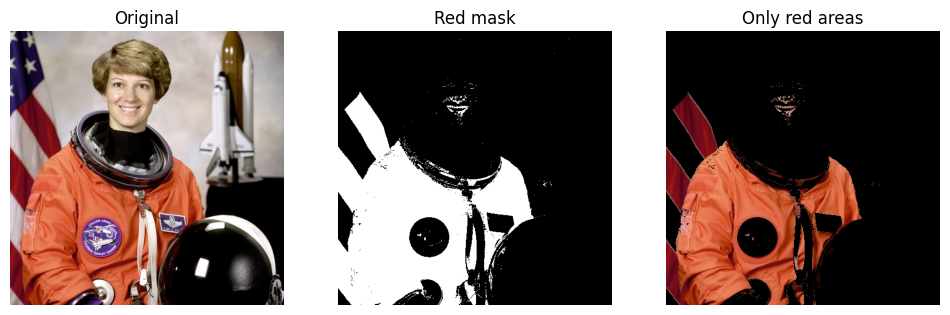

In [15]:
from skimage import data
import matplotlib.pyplot as plt
import cv2
import numpy as np

img_rgb = data.astronaut()
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

lower_red1 = np.array([0, 70, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 70, 50])
upper_red2 = np.array([179, 255, 255])

mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

mask = mask1 | mask2

result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Red mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title("Only red areas")
plt.axis("off")

plt.show()


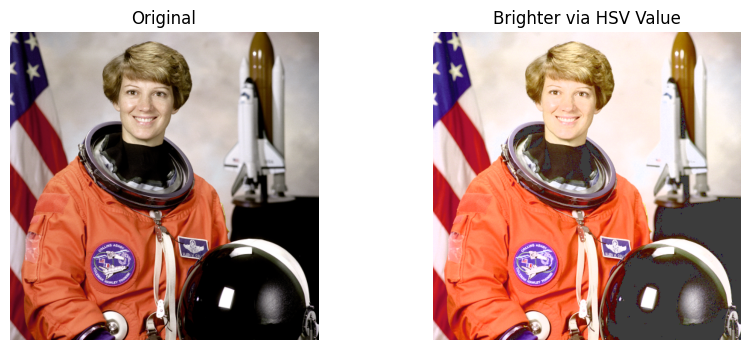

In [16]:
from skimage import data
import matplotlib.pyplot as plt
import cv2
import numpy as np

img_rgb = data.astronaut()
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

h, s, v = cv2.split(img_hsv)

v_new = np.clip(v.astype(np.int16) + 60, 0, 255).astype(np.uint8)

img_hsv_new = cv2.merge([h, s, v_new])
img_bright = cv2.cvtColor(img_hsv_new, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_bright)
plt.title("Brighter via HSV Value")
plt.axis("off")

plt.show()


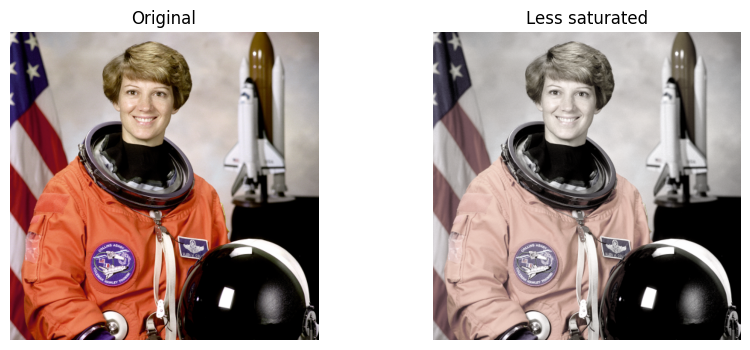

In [17]:
from skimage import data
import matplotlib.pyplot as plt
import cv2
import numpy as np

img_rgb = data.astronaut()
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

h, s, v = cv2.split(img_hsv)

s_new = (s * 0.3).astype(np.uint8)

img_hsv_new = cv2.merge([h, s_new, v])
img_less_saturated = cv2.cvtColor(img_hsv_new, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_less_saturated)
plt.title("Less saturated")
plt.axis("off")

plt.show()


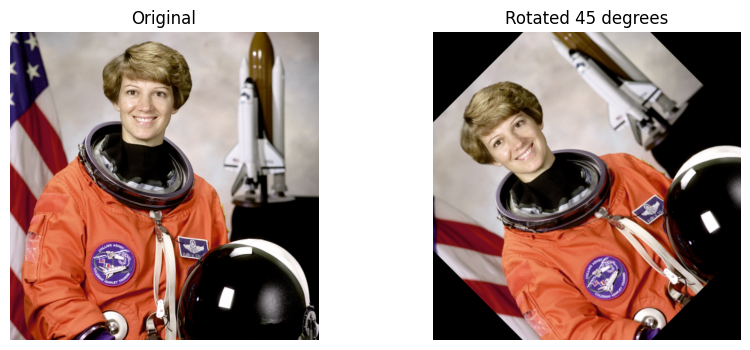

In [18]:
from skimage import data
import matplotlib.pyplot as plt
import cv2

img = data.astronaut()
h, w = img.shape[:2]

center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img, M, (w, h))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rotated)
plt.title("Rotated 45 degrees")
plt.axis("off")

plt.show()


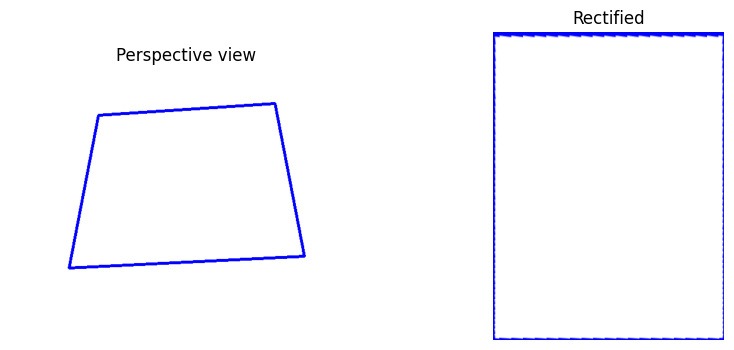

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.ones((400, 600, 3), dtype=np.uint8) * 255

pts_src = np.float32([
    [150, 80],
    [450, 60],
    [500, 320],
    [100, 340]
])

cv2.polylines(img, [pts_src.astype(np.int32)], True, (0, 0, 255), 3)

pts_dst = np.float32([
    [0, 0],
    [300, 0],
    [300, 400],
    [0, 400]
])

H = cv2.getPerspectiveTransform(pts_src, pts_dst)
warped = cv2.warpPerspective(img, H, (300, 400))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Perspective view")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(warped)
plt.title("Rectified")
plt.axis("off")

plt.show()


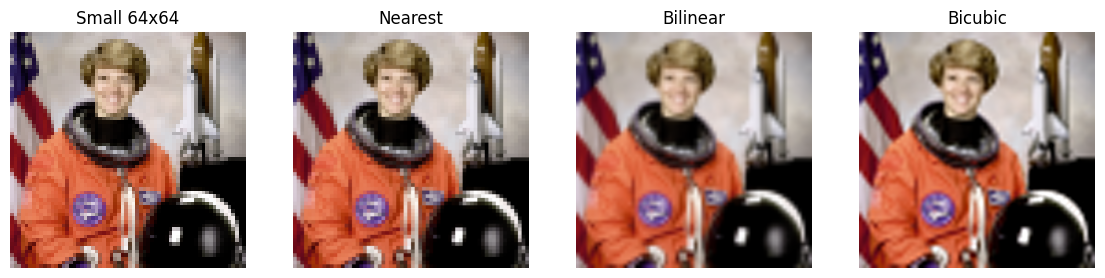

In [20]:
from skimage import data
import matplotlib.pyplot as plt
import cv2

img = data.astronaut()

small = cv2.resize(img, (64, 64), interpolation=cv2.INTER_AREA)

nearest = cv2.resize(small, (512, 512), interpolation=cv2.INTER_NEAREST)
linear = cv2.resize(small, (512, 512), interpolation=cv2.INTER_LINEAR)
cubic = cv2.resize(small, (512, 512), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(small)
plt.title("Small 64x64")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(nearest)
plt.title("Nearest")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(linear)
plt.title("Bilinear")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(cubic)
plt.title("Bicubic")
plt.axis("off")

plt.show()


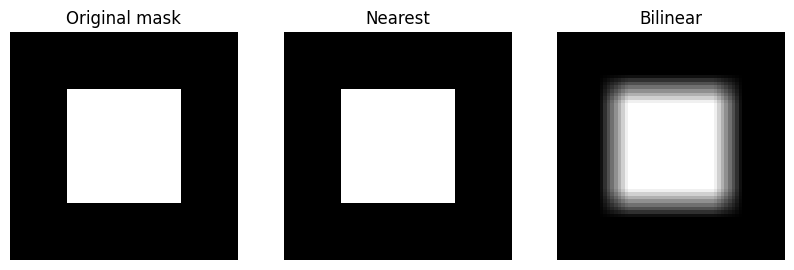

Unique nearest: [0 1]
Unique linear: [0.         0.00390625 0.01171875 0.01953125 0.02734375 0.03515625
 0.04296875 0.05078125 0.05859375 0.0625    ] ...


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

mask = np.zeros((8, 8), dtype=np.uint8)
mask[2:6, 2:6] = 1

nearest = cv2.resize(mask, (64, 64), interpolation=cv2.INTER_NEAREST)
linear = cv2.resize(mask.astype(np.float32), (64, 64), interpolation=cv2.INTER_LINEAR)

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(mask, cmap="gray")
plt.title("Original mask")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(nearest, cmap="gray")
plt.title("Nearest")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(linear, cmap="gray")
plt.title("Bilinear")
plt.axis("off")

plt.show()

print("Unique nearest:", np.unique(nearest))
print("Unique linear:", np.unique(linear)[:10], "...")


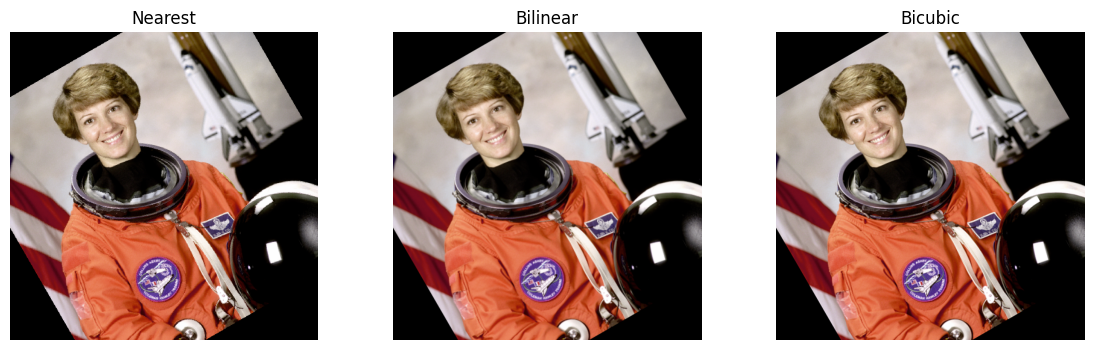

In [22]:
from skimage import data
import matplotlib.pyplot as plt
import cv2

img = data.astronaut()
h, w = img.shape[:2]

center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 30, 1.0)

rot_nearest = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_NEAREST)
rot_linear = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR)
rot_cubic = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(rot_nearest)
plt.title("Nearest")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(rot_linear)
plt.title("Bilinear")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rot_cubic)
plt.title("Bicubic")
plt.axis("off")

plt.show()


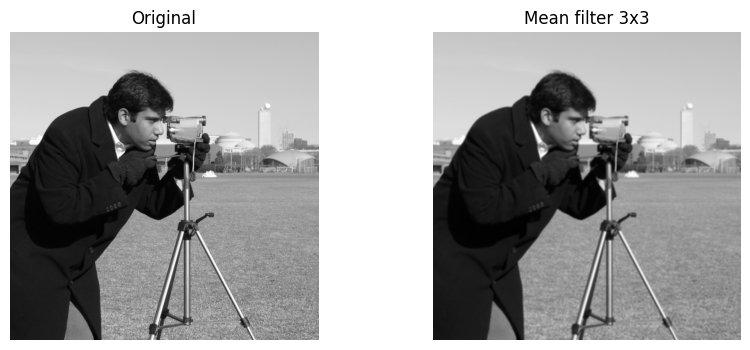

In [23]:
from skimage import data
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = data.camera()

kernel = np.ones((3, 3), dtype=np.float32) / 9
filtered = cv2.filter2D(img, -1, kernel)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(filtered, cmap="gray")
plt.title("Mean filter 3x3")
plt.axis("off")

plt.show()


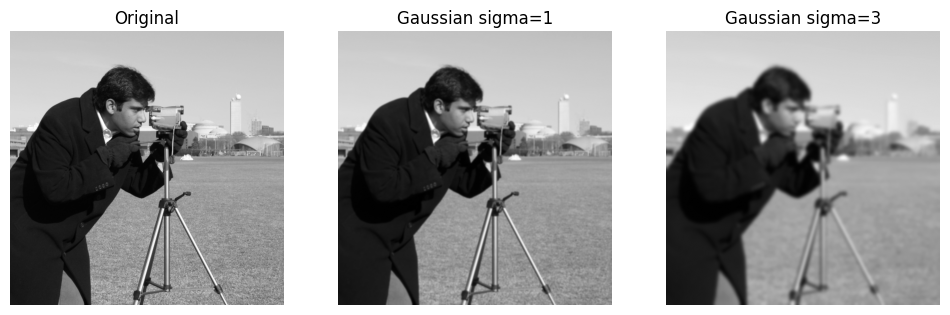

In [24]:
from skimage import data
import matplotlib.pyplot as plt
import cv2

img = data.camera()

blur_1 = cv2.GaussianBlur(img, (5, 5), 1)
blur_3 = cv2.GaussianBlur(img, (15, 15), 3)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blur_1, cmap="gray")
plt.title("Gaussian sigma=1")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blur_3, cmap="gray")
plt.title("Gaussian sigma=3")
plt.axis("off")

plt.show()


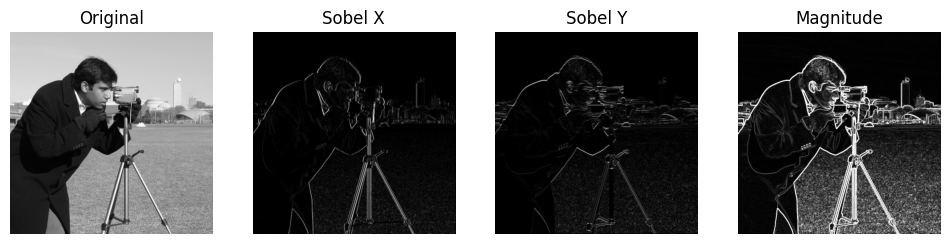

In [25]:
from skimage import data
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = data.camera()

sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

magnitude = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(np.abs(sobel_x), cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(np.abs(sobel_y), cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(magnitude, cmap="gray")
plt.title("Magnitude")
plt.axis("off")

plt.show()


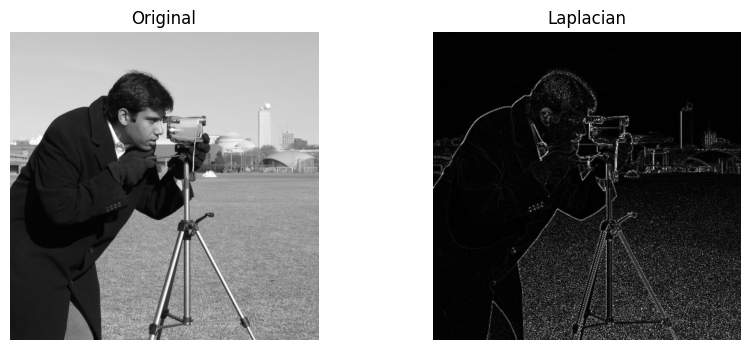

In [26]:
from skimage import data
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = data.camera()

lap = cv2.Laplacian(img, cv2.CV_64F)
lap_abs = np.abs(lap)
lap_abs = np.clip(lap_abs, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(lap_abs, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.show()


G0: (512, 512, 3)
G1: (256, 256, 3)
G2: (128, 128, 3)
G3: (64, 64, 3)


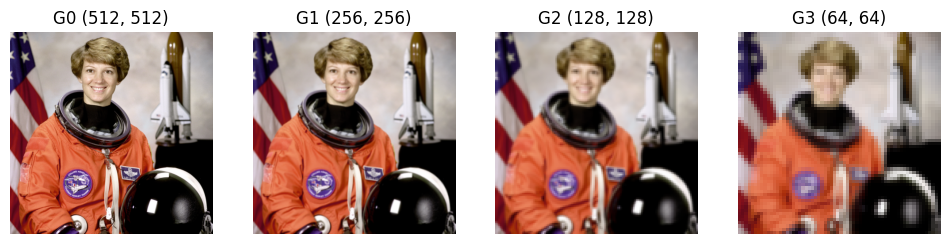

In [27]:
from skimage import data
import matplotlib.pyplot as plt
import cv2

img = data.astronaut()

g0 = img
g1 = cv2.pyrDown(g0)
g2 = cv2.pyrDown(g1)
g3 = cv2.pyrDown(g2)

print("G0:", g0.shape)
print("G1:", g1.shape)
print("G2:", g2.shape)
print("G3:", g3.shape)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(g0)
plt.title(f"G0 {g0.shape[:2]}")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(g1)
plt.title(f"G1 {g1.shape[:2]}")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(g2)
plt.title(f"G2 {g2.shape[:2]}")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(g3)
plt.title(f"G3 {g3.shape[:2]}")
plt.axis("off")

plt.show()


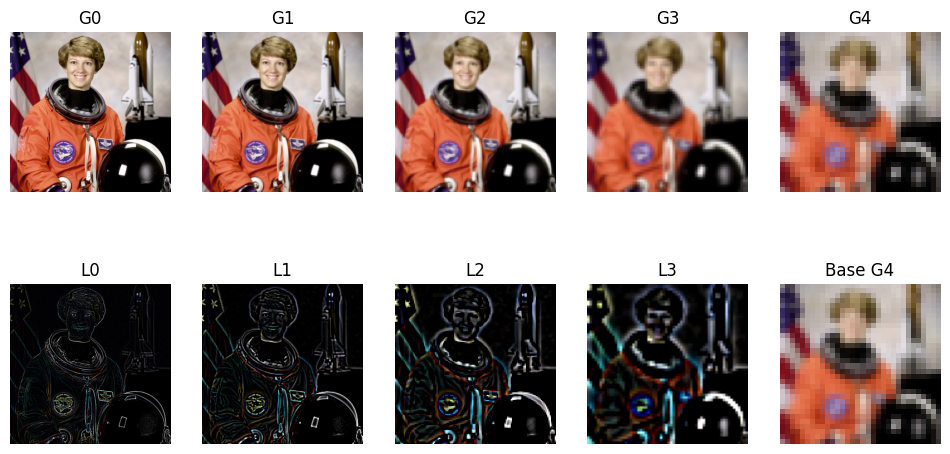

In [28]:
from skimage import data
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = data.astronaut()

gaussian = [img]
for _ in range(4):
    gaussian.append(cv2.pyrDown(gaussian[-1]))

laplacian = []

for i in range(len(gaussian) - 1):
    up = cv2.pyrUp(
        gaussian[i + 1],
        dstsize=(gaussian[i].shape[1], gaussian[i].shape[0])
    )
    lap = cv2.subtract(gaussian[i], up)
    laplacian.append(lap)

laplacian.append(gaussian[-1])

plt.figure(figsize=(12, 6))

for i, g in enumerate(gaussian):
    plt.subplot(2, len(gaussian), i + 1)
    plt.imshow(g)
    plt.title(f"G{i}")
    plt.axis("off")

for i, l in enumerate(laplacian):
    plt.subplot(2, len(gaussian), len(gaussian) + i + 1)
    if i == len(laplacian) - 1:
        plt.imshow(l)
        plt.title(f"Base G{i}")
    else:
        plt.imshow(cv2.convertScaleAbs(l, alpha=4))
        plt.title(f"L{i}")
    plt.axis("off")

plt.show()


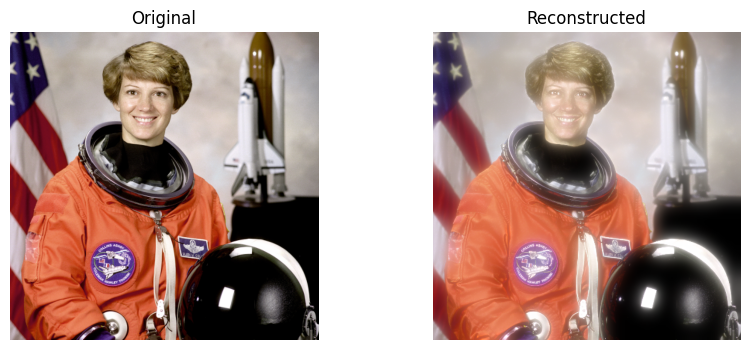

Mean absolute difference: 19.590801239013672


In [29]:
from skimage import data
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = data.astronaut()

gaussian = [img]
for _ in range(4):
    gaussian.append(cv2.pyrDown(gaussian[-1]))

laplacian = []

for i in range(len(gaussian) - 1):
    up = cv2.pyrUp(
        gaussian[i + 1],
        dstsize=(gaussian[i].shape[1], gaussian[i].shape[0])
    )
    lap = cv2.subtract(gaussian[i], up)
    laplacian.append(lap)

current = gaussian[-1]

for i in range(len(laplacian) - 1, -1, -1):
    current = cv2.pyrUp(
        current,
        dstsize=(laplacian[i].shape[1], laplacian[i].shape[0])
    )
    current = cv2.add(current, laplacian[i])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(current)
plt.title("Reconstructed")
plt.axis("off")

plt.show()

diff = cv2.absdiff(img, current)
print("Mean absolute difference:", diff.mean())


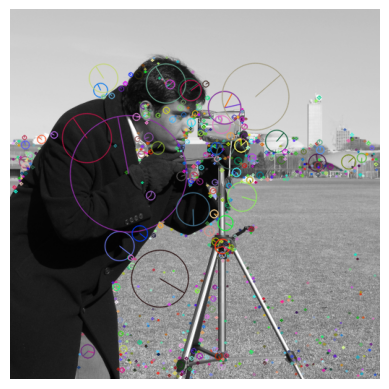

Keypoints: 791
Descriptors shape: (791, 128)


In [30]:
import cv2
from skimage import data
import matplotlib.pyplot as plt

img = data.camera()

sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(img, None)

result = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.imshow(result, cmap="gray")
plt.axis("off")
plt.show()

print("Keypoints:", len(keypoints))
print("Descriptors shape:", descriptors.shape)


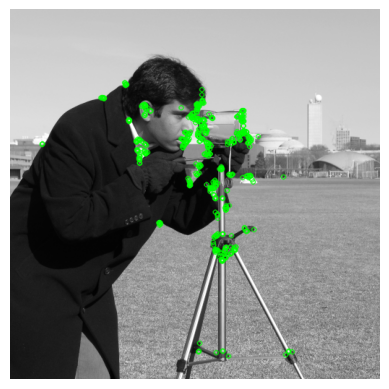

Keypoints: 500
Descriptors shape: (500, 32)
Descriptor dtype: uint8


In [31]:
import cv2
from skimage import data
import matplotlib.pyplot as plt

img = data.camera()

orb = cv2.ORB_create(nfeatures=500)
keypoints, descriptors = orb.detectAndCompute(img, None)

result = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0))

plt.imshow(result, cmap="gray")
plt.axis("off")
plt.show()

print("Keypoints:", len(keypoints))
print("Descriptors shape:", descriptors.shape)
print("Descriptor dtype:", descriptors.dtype)


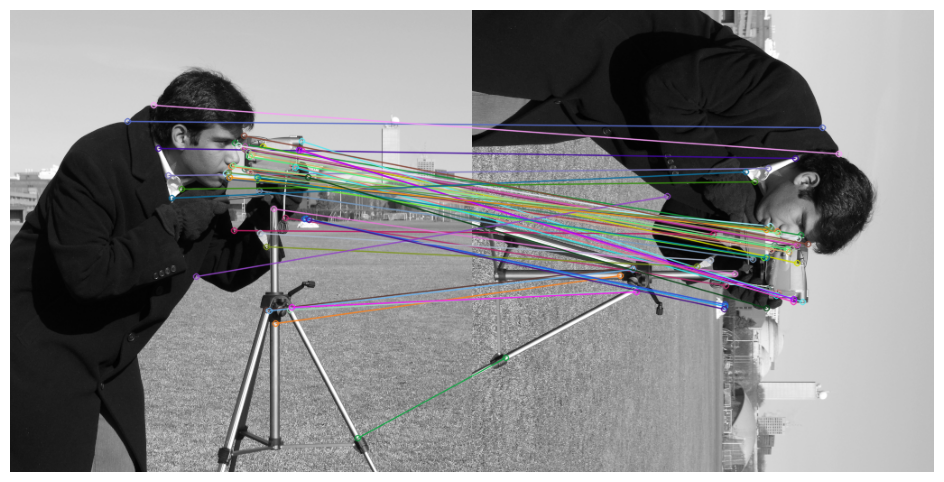

In [32]:
import cv2
from skimage import data
import matplotlib.pyplot as plt

img1 = data.camera()
img2 = cv2.rotate(img1, cv2.ROTATE_90_CLOCKWISE)

orb = cv2.ORB_create(nfeatures=500)

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

result = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(12, 6))
plt.imshow(result)
plt.axis("off")
plt.show()


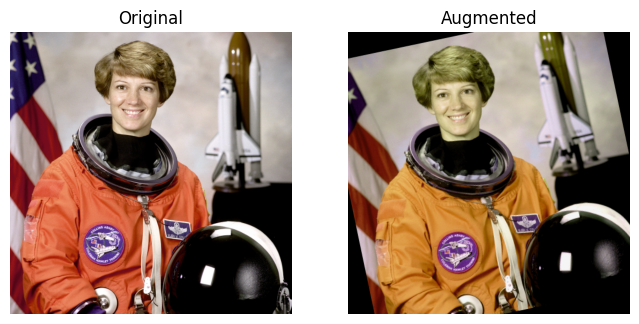

In [3]:
import albumentations as A
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.astronaut()

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.7),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.7
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=20,
        p=0.5
    ),
    A.GaussNoise(p=0.2),
])

augmented = transform(image=img)["image"]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented)
plt.title("Augmented")
plt.axis("off")

plt.show()


In [2]:
pip install albumentations

  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   - -------------------------------------- 1.6/40.1 MB 7.6 MB/s eta 0:00:06
   --- ------------------------------------ 3.4/40.1 MB 7.6 MB/s eta 0:00:05
   ----- ---------------------------------- 5.2/40.1 MB 8.2 MB/s eta 0:00:05
   ------- -------------------------------- 7.3/40.1 MB 8.4 MB/s eta 0:00:04
   -------- ------------------------------- 8.9/40.1 MB 8.3 MB/s eta 0:00:04
   ---------- ----------------------------- 10.7/40.1 MB 8.3 MB/s eta 0:00:04
   ------------ --------------------------- 12.3/40.1 MB 8.2 MB/s eta 0:00:04
   ------------- -------------------------- 13.6/40.1 MB 8.1 MB/s eta 0:00:04
   -------------- ------------------------- 14.9/40.1 MB 7.7 MB/s eta 0:00:04
   ---------------- ----------------------- 16.5/40.1 MB 7.6 MB/s eta 0:00:04
   ----------------- ---------------------- 17.8/40.1 MB 7.6 MB/s eta 0:00:03
   ---